
***

### 1. ReLU (Rectified Linear Unit)

- **Formula:**  
  $$ f(x) = \max(0, x) = \begin{cases} x & x > 0 \\ 0 & x \leq 0 \end{cases} $$
  
- **Graph:**  
  A line at zero for all negative inputs, and a linear ramp with slope 1 for positive inputs.

- **Derivative:**  
  $$ f'(x) = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases} $$

- **Why Use:**  
  Simple and computationally efficient, reduces vanishing gradient problems, introduces sparsity by zeroing negative inputs.

- **Pros:**  
  - Fast convergence  
  - Simple and effective  
  - Sparse activation promotes efficient computation  

- **Cons:**  
  - Dying ReLU problem (neurons can become inactive if inputs remain negative)  
  - Zero gradient for negative inputs  
  - Unbounded positive output can cause exploding gradients[1][2][3]

***

### 2. Leaky ReLU

- **Formula:**  
  $$ f(x) = \begin{cases} x & x > 0 \\ \alpha x & x \leq 0 \end{cases} $$  
  Typically, $$\alpha = 0.01$$

- **Graph:**  
  Similar to ReLU but with a small positive slope for negative inputs instead of a flat zero.

- **Derivative:**  
  $$ f'(x) = \begin{cases} 1 & x > 0 \\ \alpha & x \leq 0 \end{cases} $$

- **Why Use:**  
  To solve the dying ReLU problem by allowing a small gradient for negative inputs, helping neurons learn even with negative values.

- **Pros:**  
  - Prevents dead neurons  
  - Improves gradient flow  
  - Slightly better performance in some deep networks

- **Cons:**  
  - The slope $$\alpha$$ is fixed and must be set manually, which is a hyperparameter to tune[4][5][1]

***

### 3. Parametric ReLU (PReLU)

- **Formula:**  
  $$ f(x) = \begin{cases} x & x > 0 \\ a x & x \leq 0 \end{cases} $$  
  Where $$a$$ is a learned parameter during training (unlike fixed $$\alpha$$ in Leaky ReLU).

- **Graph:**  
  Similar to Leaky ReLU but the negative slope adapts during training.

- **Derivative:**  
  $$ f'(x) = \begin{cases} 1 & x > 0 \\ a & x \leq 0 \end{cases} $$

- **Why Use:**  
  Learns the slope for negative values dynamically to better adapt to the data, potentially outperforming fixed-slope variants.

- **Pros:**  
  - Flexible and adaptive  
  - Can improve model accuracy  
  - Mitigates dying neuron problem better than fixed Leaky ReLU

- **Cons:**  
  - Additional parameters can lead to overfitting if not managed  
  - Slightly higher computational cost[6][1][4]

***

### 4. ELU (Exponential Linear Unit)

- **Formula:**  
  $$ f(x) = \begin{cases} x & x > 0 \\ \alpha (e^x - 1) & x \leq 0 \end{cases} $$  
  with $$\alpha$$ usually set to 1.

- **Graph:**  
  Linear for positive inputs, smoothly approaches $$-\alpha$$ for negative inputs.

- **Derivative:**  
  $$ f'(x) = \begin{cases} 1 & x > 0 \\ \alpha e^x & x \leq 0 \end{cases} $$

- **Why Use:**  
  Addresses dying ReLU problem by allowing negative outputs and providing smooth gradients, helps improve learning dynamics and convergence speed.

- **Pros:**  
  - Smooth transition for negative inputs  
  - Negative outputs allow mean activations closer to zero, reducing bias shifts  
  - Faster convergence in some cases

- **Cons:**  
  - More computationally expensive due to exponential  
  - Output can be unbounded positively  
  - Slightly more complex than ReLU variants[7][8][1]

***

### 5. SELU (Scaled Exponential Linear Unit)

- **Formula:**  
  $$ f(x) = \begin{cases} \lambda x & x > 0 \\ \lambda \alpha (e^x - 1) & x \leq 0 \end{cases} $$  
  where $$\alpha \approx 1.67326$$ and $$\lambda \approx 1.0507$$.

- **Graph:**  
  Similar to ELU but scaled to maintain mean zero and unit variance for self-normalization.

- **Derivative:**  
  Same form as ELU multiplied by $$\lambda$$, maintaining self-normalizing property.

- **Why Use:**  
  Designed to keep activations standardized (mean 0, variance 1) automatically through layers, reducing need for batch normalization and improving training stability.

- **Pros:**  
  - Self-normalizing properties for stable, fast training  
  - Reduces internal covariate shift  
  - Improves generalization in deep networks

- **Cons:**  
  - Works best with specific initialization (LeCun normal) and dropout (alpha dropout)  
  - Slightly more complex  
  - Less commonly used outside fully connected dense networks[9][10]

***

### Summary Table Comparison

| Activation Function | Formula | Negative Input Behavior | Learnable Parameters | Pros | Cons |
|---------------------|---------|-------------------------|---------------------|------|------|
| ReLU                | $$ \max(0,x) $$ | Output 0 | No | Simple, fast, sparse activations | Dying ReLU, zero gradient for $$x 0$$, else $$\alpha (e^x -1)$$ | Smooth negative curve | No | Smooth, negative outputs, faster convergence | Computationally expensive |
| SELU                | Scaled ELU with $$\lambda, \alpha$$ | Scaled smooth negative | No (fixed scale) | Self-normalizing, stable training | Requires specific init & dropout |

***

The graphs of these functions can be roughly described as:

- ReLU: Flat zero for negatives, linear positive.
- Leaky ReLU / PReLU: Linear with small slope for negatives, slope 1 positive.
- ELU: Exponential smoothing in negative region, linear positive.
- SELU: Like ELU but scaled for self-normalization.

***

### Why Use Variants of ReLU?

- To overcome **dying ReLU** problem where neurons output zero gradient on negative inputs and stop learning.
- To allow **negative outputs and smoother gradients** (ELU, SELU) to improve learning dynamics.
- To enable **learnable parameters for negative slopes** (PReLU) for adaptive behavior.
- To improve **training stability and convergence speed** especially in deep networks (SELU).

***

This should give a comprehensive picture of different ReLU variants, their math, intuition, derivatives, and trade-offs for practical neural network design.



[1] https://www.geeksforgeeks.org/deep-learning/relu-activation-function-in-deep-learning/
[2] https://builtin.com/machine-learning/relu-activation-function
[3] https://1cademy.com/node/pros-and-cons-of-relu/y3jLboZbwdmadKadNv8t
[4] https://www.pythonkitchen.com/relu-activation-function-and-its-variants/
[5] https://www.geeksforgeeks.org/machine-learning/Leaky-Relu-Activation-Function-in-Deep-Learning/
[6] https://www.educative.io/answers/what-is-parametric-relu
[7] https://www.geeksforgeeks.org/deep-learning/elu-activation-function-in-neural-network/
[8] https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html
[9] https://www.geeksforgeeks.org/deep-learning/selu-activation-function-in-neural-network/
[10] https://github.com/christianversloot/machine-learning-articles/blob/main/using-selu-with-tensorflow-and-keras.md
[11] https://www.kaggle.com/getting-started/337328
[12] https://en.wikipedia.org/wiki/Rectifier_(neural_networks)
[13] https://apxml.com/courses/introduction-to-deep-learning/chapter-2-activation-functions-architecture/relu-variants
[14] https://stackoverflow.com/questions/42042561/relu-derivative-in-backpropagation
[15] https://www.v7labs.com/blog/neural-networks-activation-functions
[16] https://www.sciencedirect.com/topics/computer-science/parametric-rectified-linear-unit
[17] https://www.educative.io/answers/what-is-leaky-relu
[18] https://www.baeldung.com/cs/relu-vs-leakyrelu-vs-prelu
[19] https://www.kaggle.com/code/dansbecker/rectified-linear-units-relu-in-deep-learning
[20] https://data-intelligence.hashnode.dev/comprehensive-guide-to-the-relu-activation-function-in-neural-networks-definition-role-and-type-explained

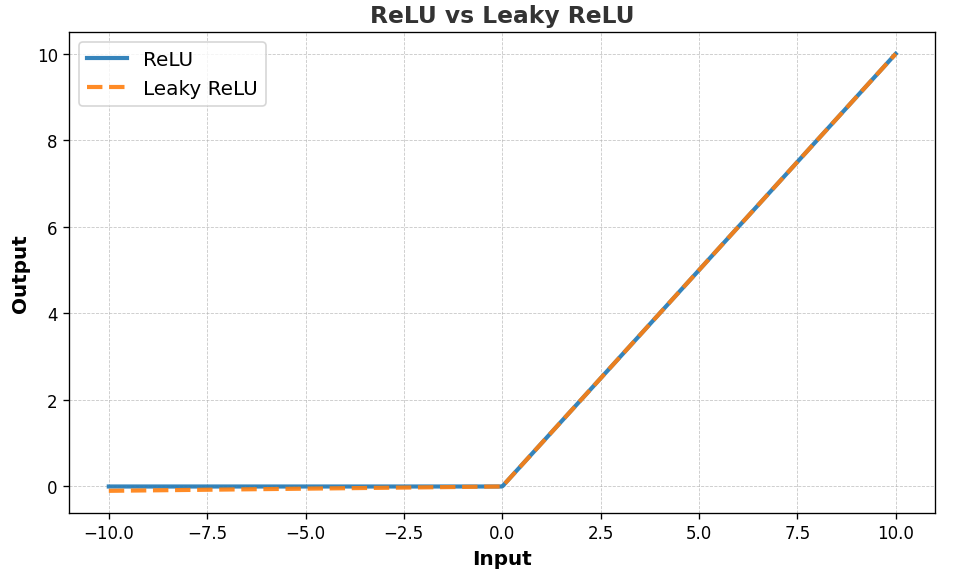

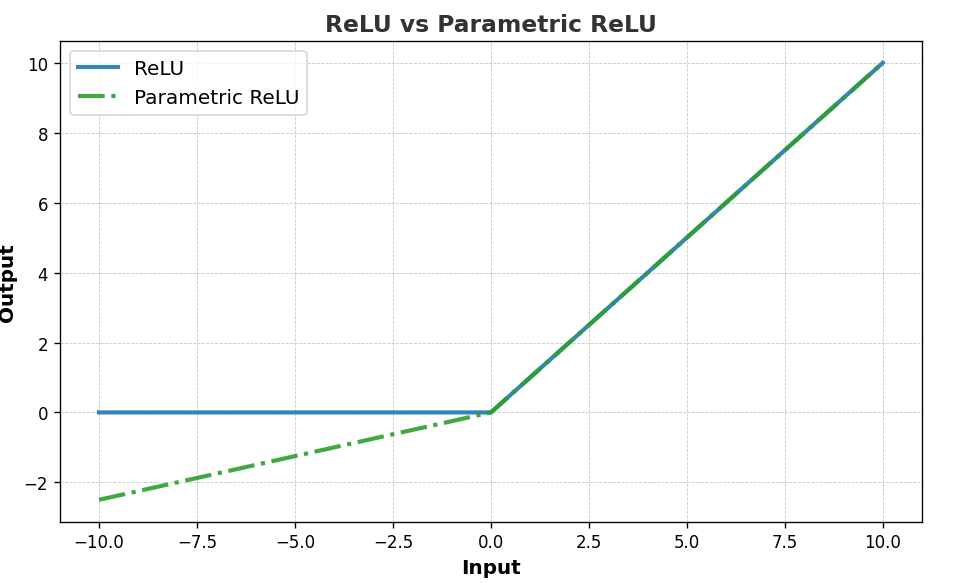

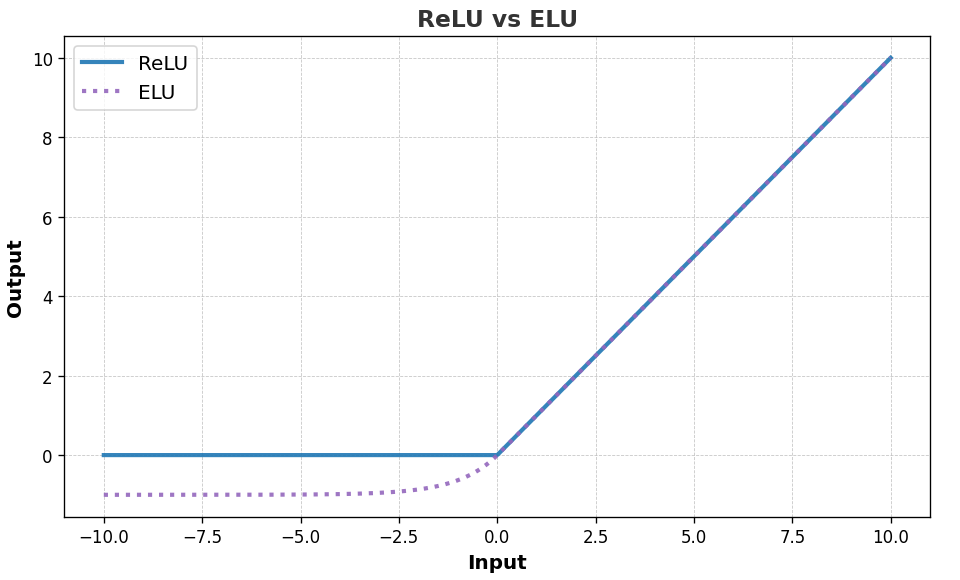

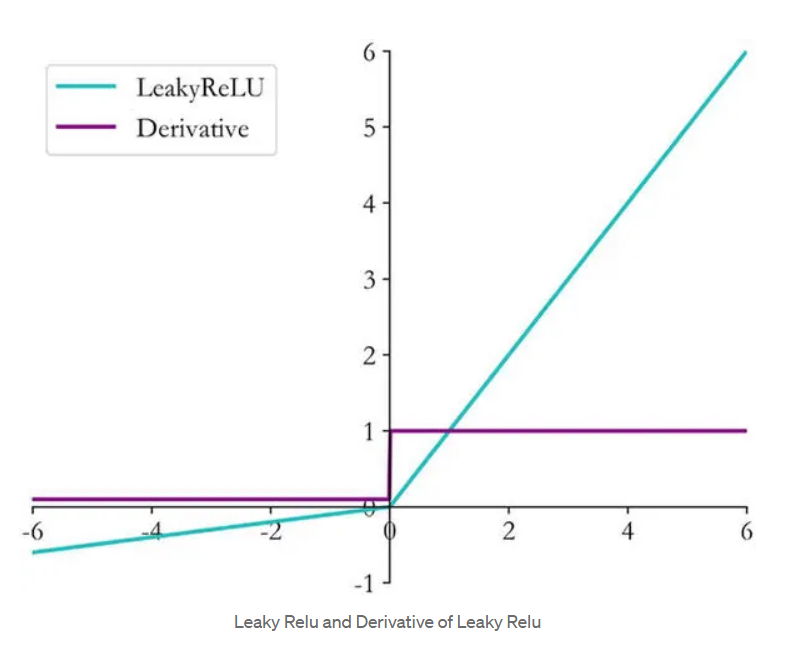

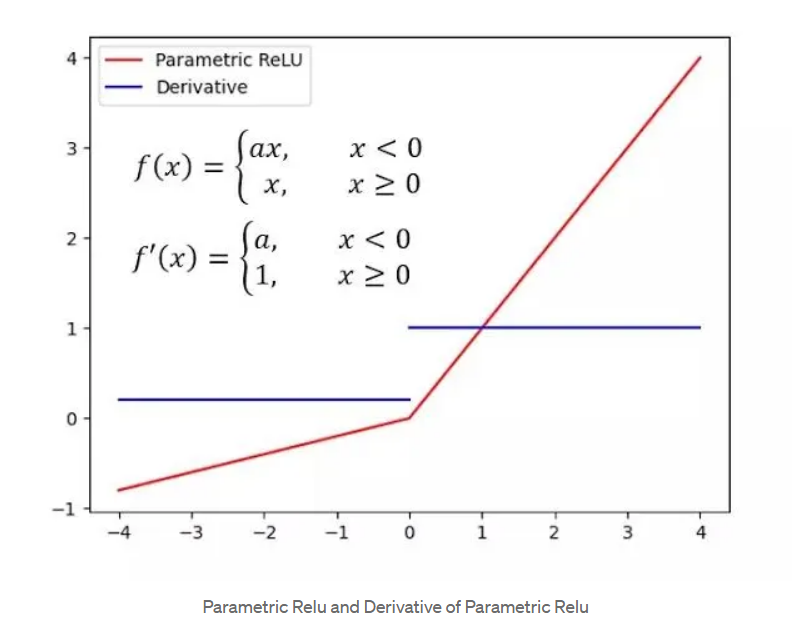

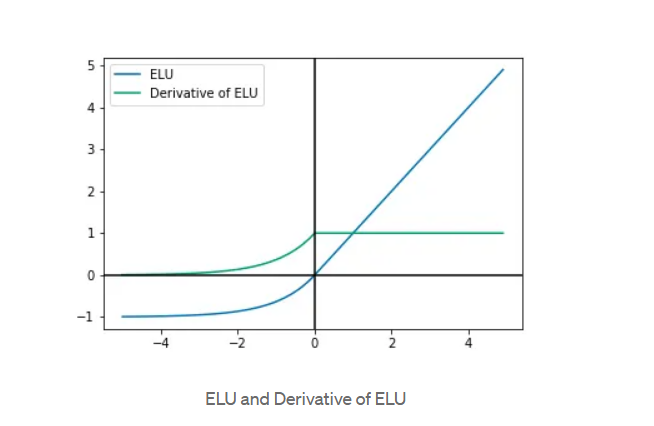

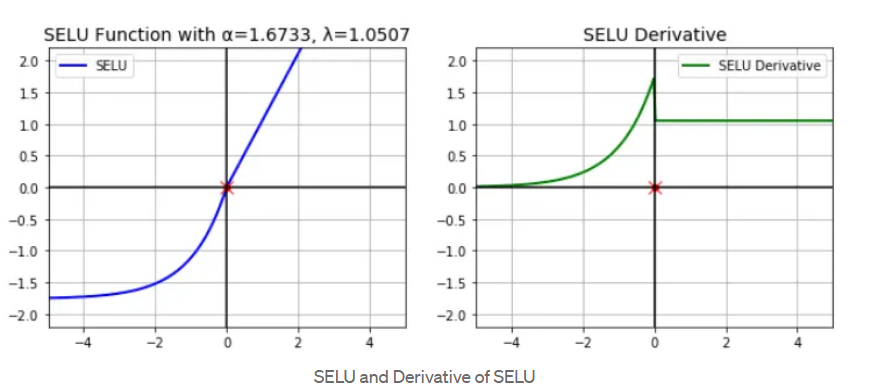

The "dying ReLU" problem refers to a situation in neural networks where a significant number of neurons using the ReLU (Rectified Linear Unit) activation function become inactive and effectively stop learning. This happens because these neurons output zero for all inputs, which means their gradients are zero during backpropagation, preventing them from updating their weights.

### How It Occurs:
- **ReLU function:** $$ f(x) = \max(0, x) $$ outputs zero for any input $$ x \leq 0 $$.
- During training, if a neuron's input consistently falls into the negative region, the output of that neuron is zero.
- Because the derivative of ReLU is zero for negative inputs, the gradient that flows through that neuron is zero.
- With zero gradient, the neuron's weights do not update during backpropagation.
- As a result, the neuron becomes "dead" or "dying" because it no longer contributes to learning or the network's output.
- This situation can worsen over time if many neurons become stuck like this, limiting the model's capacity and performance.

The dying ReLU problem arises mainly due to large negative biases or weight updates pushing inputs to the negative side permanently.

To mitigate this issue, variants like Leaky ReLU, Parametric ReLU, ELU, and SELU allow small or smooth gradients for negative inputs so that neurons continue learning even when their inputs are negative. This helps prevent neurons from becoming inactive and improves training stability and model accuracy.


**When neurons using ReLU get stuck outputting zero for all inputs because their input is always negative, they stop learning and can't update their weights.**

### How to Solve It (Minimalist):
- Use activation variants that allow a small non-zero gradient for negative inputs, such as:
  - Leaky ReLU (small slope like 0.01 for negatives)
  - Parametric ReLU (learnable slope for negatives)
  - ELU or SELU (smooth negative outputs and gradients)
- These variants keep gradients flowing even when inputs are negative, preventing neurons from "dying."

In essence:  
**Allow a "little" gradient on the negative side instead of zero to keep neurons alive and learning.**